Error: No files found matching the pattern './data/multimodal_ground_truth_train_part*.csv'. Please check the folder path!
Found 4 files to merge: ['./data/multimodal_ground_truth_test_part0.csv', './data/multimodal_ground_truth_test_part1.csv', './data/multimodal_ground_truth_test_part2.csv', './data/multimodal_ground_truth_test_part3.csv']

--- Dataset Statistics: ./data/multimodal_ground_truth_test_final.csv ---
Total Rows: 10650
Average Judge Score: 8.74/10
Percentage of 9+ Scores: 94.3%

--- Performance by Emotion ---
                  mean       std  count
User_Emotion                           
confusedly    8.764086  1.559029   2183
happily       8.550361  2.109295   2075
neutrally     8.738684  1.720919   2143
sadly         8.890943  1.573042   2164
whispers      8.746283  1.881670   2085


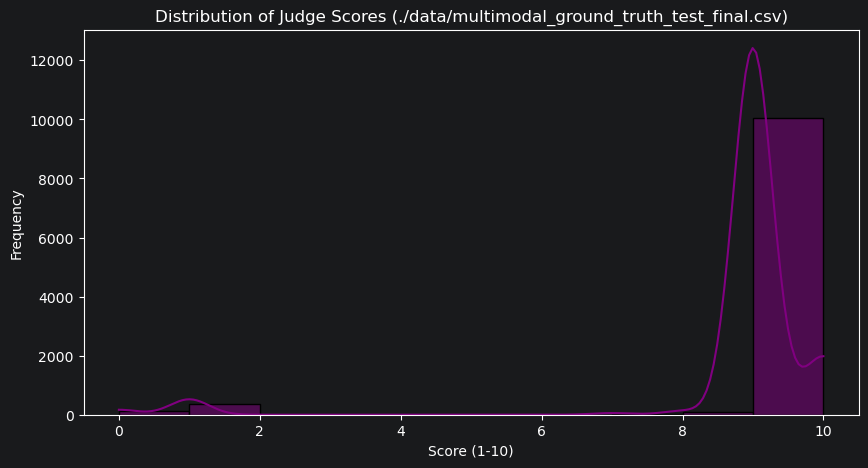

In [2]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import sys

def process_ground_truth(file_pattern, output_name):
    # 1. Load and Merge
    all_files = sorted(glob.glob(file_pattern))

    # SAFETY CHECK: Make sure files were actually found
    if not all_files:
        print(f"Error: No files found matching the pattern '{file_pattern}'. Please check the folder path!")
        return None

    print(f"Found {len(all_files)} files to merge: {all_files}")
    df = pd.concat([pd.read_csv(f) for f in all_files], ignore_index=True)

    # 2. Metric Preparation
    df['Judge_Score'] = pd.to_numeric(df['Judge_Score'], errors='coerce')
    df = df.dropna(subset=['Judge_Score'])

    print(f"\n--- Dataset Statistics: {output_name} ---")
    print(f"Total Rows: {len(df)}")
    print(f"Average Judge Score: {df['Judge_Score'].mean():.2f}/10")
    print(f"Percentage of 9+ Scores: {(df['Judge_Score'] >= 9).mean()*100:.1f}%")

    # 3. Quality Analysis by Emotion
    if 'User_Emotion' in df.columns:
        emotion_stats = df.groupby('User_Emotion')['Judge_Score'].agg(['mean', 'std', 'count'])
        print("\n--- Performance by Emotion ---")
        print(emotion_stats)

    # 4. Visualization
    plt.figure(figsize=(10, 5))
    sns.histplot(df['Judge_Score'], bins=10, kde=True, color='purple')
    plt.title(f'Distribution of Judge Scores ({output_name})')
    plt.xlabel('Score (1-10)')
    plt.ylabel('Frequency')
    plt.show()

    # 5. Export for Step 1.4
    df.to_csv(output_name, index=False)
    return df

# Run for both sets (FIXED THE PATTERNS HERE)
# Removed the underscore between "part" and "*"
train_df = process_ground_truth('./data/multimodal_ground_truth_train_part*.csv', './data/multimodal_ground_truth_train_final.csv')
test_df = process_ground_truth('./data/multimodal_ground_truth_test_part*.csv', './data/multimodal_ground_truth_test_final.csv')